# ⚽Projet IA Football - Fontanié Mathis & Hamoudi Malak




# Modèle de Clustering sur les Joueurs 


## Chargement et aperçu des données



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer

# Chargement des fichiers
df_home = pd.read_csv('data/X_Train_Data/train_home_player_statistics_df.csv')
df_away = pd.read_csv('data/X_Train_Data/train_away_player_statistics_df.csv')

# Fusionner les deux
df_home["HOME_OR_AWAY"] = "HOME"
df_away["HOME_OR_AWAY"] = "AWAY"
df_all = pd.concat([df_home, df_away], ignore_index=True)

# Aperçu
print("Shape après fusion :", df_all.shape)
df_all.head()

# Affiche toutes les colonnes
print("\nColonnes :")
for col in df_all.columns:
    print("-", col)
    

Shape après fusion : (473211, 308)

Colonnes :
- ID
- LEAGUE
- TEAM_NAME
- POSITION
- PLAYER_NAME
- PLAYER_ACCURATE_CROSSES_season_sum
- PLAYER_ACCURATE_PASSES_season_sum
- PLAYER_AERIALS_WON_season_sum
- PLAYER_ASSISTS_season_sum
- PLAYER_BIG_CHANCES_CREATED_season_sum
- PLAYER_BIG_CHANCES_MISSED_season_sum
- PLAYER_BLOCKED_SHOTS_season_sum
- PLAYER_CAPTAIN_season_sum
- PLAYER_CLEARANCES_season_sum
- PLAYER_CLEARANCE_OFFLINE_season_sum
- PLAYER_DISPOSSESSED_season_sum
- PLAYER_DRIBBLED_ATTEMPTS_season_sum
- PLAYER_DRIBBLED_PAST_season_sum
- PLAYER_DUELS_LOST_season_sum
- PLAYER_DUELS_WON_season_sum
- PLAYER_ERROR_LEAD_TO_GOAL_season_sum
- PLAYER_FOULS_season_sum
- PLAYER_FOULS_DRAWN_season_sum
- PLAYER_GOALKEEPER_GOALS_CONCEDED_season_sum
- PLAYER_GOALS_season_sum
- PLAYER_GOALS_CONCEDED_season_sum
- PLAYER_HIT_WOODWORK_season_sum
- PLAYER_INTERCEPTIONS_season_sum
- PLAYER_KEY_PASSES_season_sum
- PLAYER_MINUTES_PLAYED_season_sum
- PLAYER_OFFSIDES_season_sum
- PLAYER_OWN_GOALS_season_s

##  Nettoyage et filtrage des données



In [ ]:
# Supprimer les colonnes avec trop de NaN
seuil_nan = 0.4 
df_nan_filtered = df_all.loc[:, df_all.isna().mean() < seuil_nan]

# Ne garder que les colonnes numériques
df_numeric = df_nan_filtered.select_dtypes(include='number')

# Éliminer les colonnes à faible variance
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(df_numeric)

# Récupérer les noms des colonnes sélectionnées
selected_cols = df_numeric.columns[selector.get_support()]
df_filtered = pd.DataFrame(X_filtered, columns=selected_cols)

print("Shape après filtrage intelligent :", df_filtered.shape)
print("Nombre de NaN restants :", df_filtered.isna().sum().sum())



Shape après filtrage intelligent : (473211, 272)
Nombre de NaN restants : 14632373


## Imputation et normalisation



In [ ]:

# Imputer les NaN par la médiane
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_filtered)

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Vérification
print("Y a-t-il encore des NaN ?", np.isnan(X_scaled).sum())

print("Moyenne globale après standardisation :", round(X_scaled.mean(), 4))
print("Écart-type global :", round(X_scaled.std(), 4))


Y a-t-il encore des NaN ? 0
Moyenne globale après standardisation : -0.0
Écart-type global : 1.0


##  Réduction de dimension (PCA)


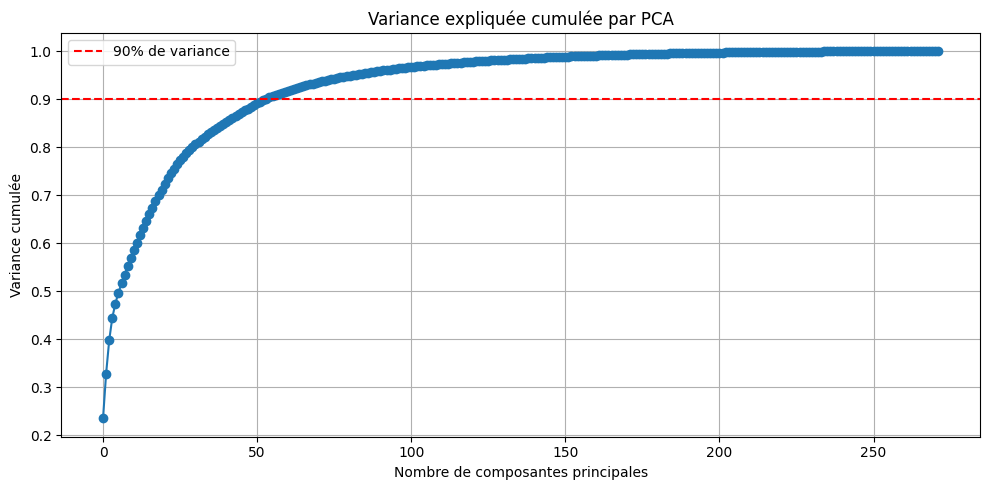

In [ ]:

# PCA sans reduction afin d'analyser la variance
pca = PCA()
pca.fit(X_scaled)

# Plot de la variance cumulée
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Variance expliquée cumulée par PCA")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance cumulée")
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% de variance')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# On garde 3 composantes principales
pca_final = PCA(n_components=3, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print("Shape après PCA :", X_pca.shape)


Shape après PCA : (473211, 3)


## Choix du nombre de clusters (KMeans + Silhouette Score)


Silhouette score pour k = 2 : 0.4012
Silhouette score pour k = 3 : 0.4053
Silhouette score pour k = 4 : 0.4673
Silhouette score pour k = 5 : 0.4357
Silhouette score pour k = 6 : 0.4194
Silhouette score pour k = 7 : 0.4156
Silhouette score pour k = 8 : 0.3992
Silhouette score pour k = 9 : 0.3869
Silhouette score pour k = 10 : 0.3506


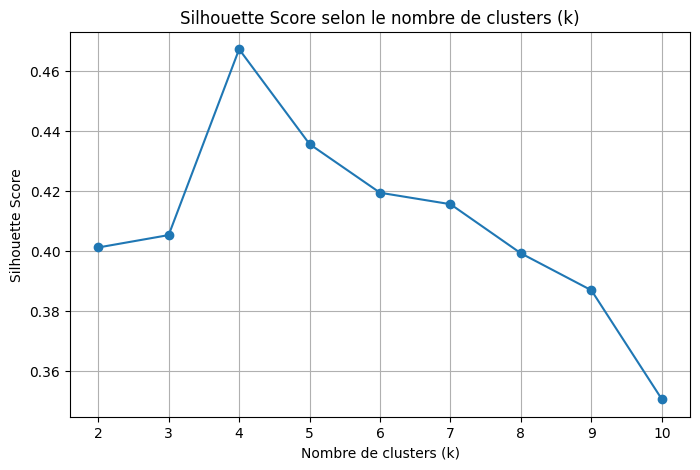

In [ ]:

# Échantillonnage pour ne pas surcharger la RAM
np.random.seed(42)
sample_indices = np.random.choice(X_pca.shape[0], size=10000, replace=False)
X_sample = X_pca[sample_indices]

# Tester plusieurs valeurs de k
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)
    print(f"Silhouette score pour k = {k} : {score:.4f}")

# Affichage du score en fonction de k
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title("Silhouette Score selon le nombre de clusters (k)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


## Clustering final et visualisation 2D


Nombre de joueurs par cluster :
Cluster
0     77298
1    115167
2     87201
3    193545
Name: count, dtype: int64


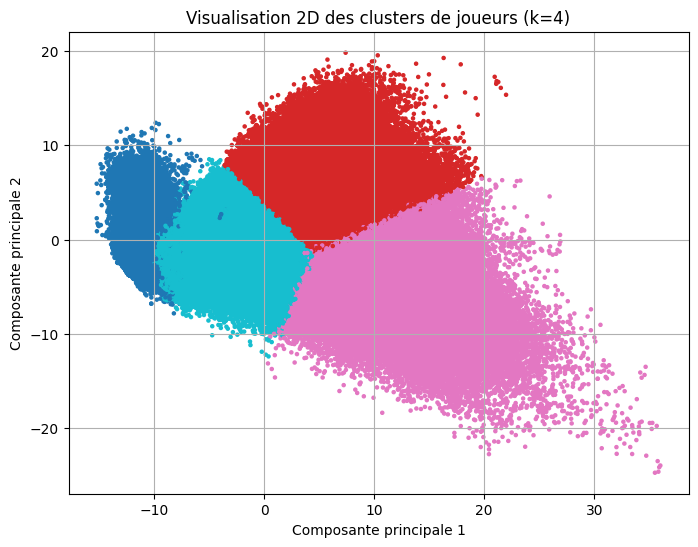

In [ ]:

# Appliquer KMeans avec k = 4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init='auto')
labels_final = kmeans_final.fit_predict(X_pca)

# Ajouter les labels dans le DataFrame original
df_all['Cluster'] = labels_final

# Affichage du nombre de joueurs par cluster
print("Nombre de joueurs par cluster :")
print(df_all['Cluster'].value_counts().sort_index())

# Pour visualiser les clusters, PCA à 2D  pour l'affichage
pca_visu = PCA(n_components=2, random_state=42)
X_visu = pca_visu.fit_transform(X_scaled)

# Affichage en 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_visu[:, 0], X_visu[:, 1], c=labels_final, cmap='tab10', s=5)
plt.title("Visualisation 2D des clusters de joueurs (k=4)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.grid(True)
plt.show()


In [ ]:
# On repart des colonnes numériques filtrées avant PCA
# On ajoute les labels de cluster pour pouvoir grouper
df_clustered = df_filtered.copy()
df_clustered['Cluster'] = labels_final

# Calcul des moyennes par cluster
cluster_means = df_clustered.groupby('Cluster').mean()

# Affichage des moyennes
print("Moyennes des variables par cluster :")
display(cluster_means)


Moyennes des variables par cluster :


,ID,PLAYER_ACCURATE_CROSSES_season_sum,PLAYER_ACCURATE_PASSES_season_sum,PLAYER_AERIALS_WON_season_sum,PLAYER_ASSISTS_season_sum,PLAYER_BIG_CHANCES_CREATED_season_sum,PLAYER_BIG_CHANCES_MISSED_season_sum,PLAYER_BLOCKED_SHOTS_season_sum,PLAYER_CLEARANCES_season_sum,PLAYER_CLEARANCE_OFFLINE_season_sum,...,PLAYER_SAVES_INSIDE_BOX_5_last_match_std,PLAYER_SHOTS_BLOCKED_5_last_match_std,PLAYER_SHOTS_ON_TARGET_5_last_match_std,PLAYER_SHOTS_TOTAL_5_last_match_std,PLAYER_STARTING_LINEUP_5_last_match_std,PLAYER_SUCCESSFUL_DRIBBLES_5_last_match_std,PLAYER_TACKLES_5_last_match_std,PLAYER_TOTAL_CROSSES_5_last_match_std,PLAYER_TOTAL_DUELS_5_last_match_std,PLAYER_YELLOWCARDS_5_last_match_std
Cluster,,,,,,,,,,,,,,,,,,,,,
0,6155.076302,0.087477,7.302220,1.424192,0.504437,0.227479,0.128653,0.194944,3.864237,0.028789,...,15.675149,0.302090,0.274292,0.559011,8.872713,0.591274,1.125097,0.399481,2.808141,5.491112
1,6137.726502,7.969679,43.186138,24.235085,7.949230,7.852292,3.874524,27.455741,33.043606,7.216208,...,0.000000,25.437647,11.996003,19.133526,28.358710,15.609755,35.564421,12.792360,33.361830,42.103963
2,6158.385477,20.373994,27.255741,17.365735,25.417289,26.004794,22.338825,5.904996,7.941436,1.437959,...,0.000000,29.580449,35.912849,39.739214,34.692840,30.470614,26.319457,24.637582,37.426642,32.127485
3,6154.923346,4.393954,11.317817,6.404135,6.216689,4.827987,4.262273,4.602894,6.041893,1.011242,...,0.000207,11.689773,10.437581,15.799276,44.880339,10.938243,18.393117,11.135110,28.977875,19.842198


## Analyse des clusters


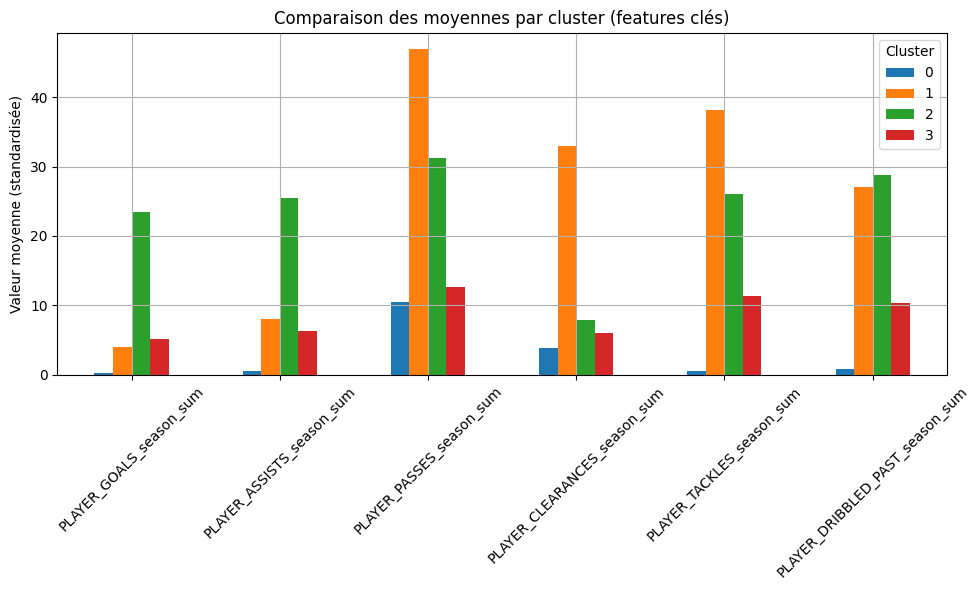

In [ ]:

# Choisir les variables les plus représentatives 
top_features = [
    'PLAYER_GOALS_season_sum',
    'PLAYER_ASSISTS_season_sum',
    'PLAYER_PASSES_season_sum',
    'PLAYER_CLEARANCES_season_sum',
    'PLAYER_TACKLES_season_sum',
    'PLAYER_DRIBBLED_PAST_season_sum'
]

# Création d’un DataFrame des moyennes par cluster
df_clustered = df_filtered.copy()
df_clustered['Cluster'] = df_all['Cluster']
cluster_means = df_clustered.groupby('Cluster')[top_features].mean()

# Visualisation
cluster_means.T.plot(kind='bar', figsize=(10, 6))
plt.title("Comparaison des moyennes par cluster (features clés)")
plt.ylabel("Valeur moyenne (standardisée)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Interprétation graphique des clusters (features clés)

Le graphique ci-dessus compare les moyennes de six variables clés pour chaque cluster de joueurs.

#### Observations principales :

- **Cluster 2** : très haut niveau sur `PLAYER_GOALS_season_sum` (buts), `PLAYER_ASSISTS_season_sum` (passes décisives), et `PLAYER_PASSES_season_sum` (passes) → profils très offensifs.
- **Cluster 1** : scores élevés sur `PLAYER_PASSES_season_sum` (passes), `PLAYER_CLEARANCES_season_sum` (dégagements) et `PLAYER_TACKLES_season_sum` (tacles) → profils défensifs complets.
- **Cluster 3** : moyennes modérées sur toutes les features, dont `PLAYER_DRIBBLED_PAST_season_sum` (fois où le joueur s’est fait dribbler) → joueurs actifs mais équilibrés.
- **Cluster 0** : très faibles sur toutes les métriques → probablement des joueurs peu utilisés ou remplaçants.

Ce graphique montre que chaque cluster se distingue par des caractéristiques de jeu bien spécifiques.
